# Rental Pricing Prediction: Data Exploration & Baseline Model
---
**Objective:** Build a predictive model to estimate monthly rental prices (`rent_eur_month`) based on property features.

## 1. Environment Setup & Data Loading
First, let's import our essential data science libraries (`pandas`, `numpy`, `seaborn`, and `matplotlib`) and separate our training and testing data into features ($X$) and targets ($Y$).

In [4]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_train = pd.read_csv("track_a_rental_pricing_train.csv")
df_test = pd.read_csv("track_a_rental_pricing_test.csv")

X_train = df_train.drop(columns=['rent_eur_month'])
Y_train = df_train['rent_eur_month']

X_test = df_test.drop(columns= ['rent_eur_month'])
Y_test = df_test['rent_eur_month']

## 2. Exploratory Data Analysis (EDA)
### 2.1 Feature Correlation Heatmap
Before building a model, **we want to inspect** how different numeric features correlate with our target variable (`rent_eur_month`). 

Because rental data often contains mixed integers (like bedrooms) and binary indicators, we use the **Spearman rank correlation** to uncover both linear and non-linear monotonic relationships.

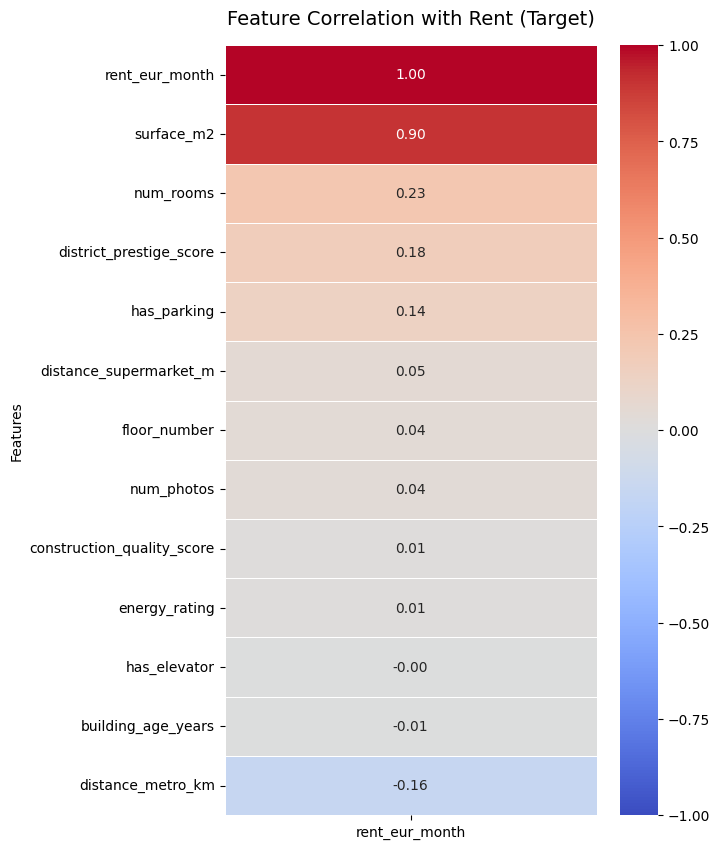

In [5]:
df_train_numeric = df_train.select_dtypes(include=['number'])
numeric_df = df_train.select_dtypes(include=["number"])

corr_matrix = numeric_df.corr(method="spearman")
rent_corr = corr_matrix[["rent_eur_month"]].sort_values(by="rent_eur_month", ascending=False)
plt.figure(figsize=(6, 10))
sns.heatmap(
    rent_corr,
    annot=True,  
    cmap="coolwarm",  
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title("Feature Correlation with Rent (Target)", fontsize=14, pad=15)
plt.ylabel("Features")
plt.show()

### 2.2 Global Correlation Matrix
Now let's expand our view to see the full correlation matrix. **We want to try** to identify multi-collinearity (features that are highly correlated with each other, not just the target), which can impact linear model stability.

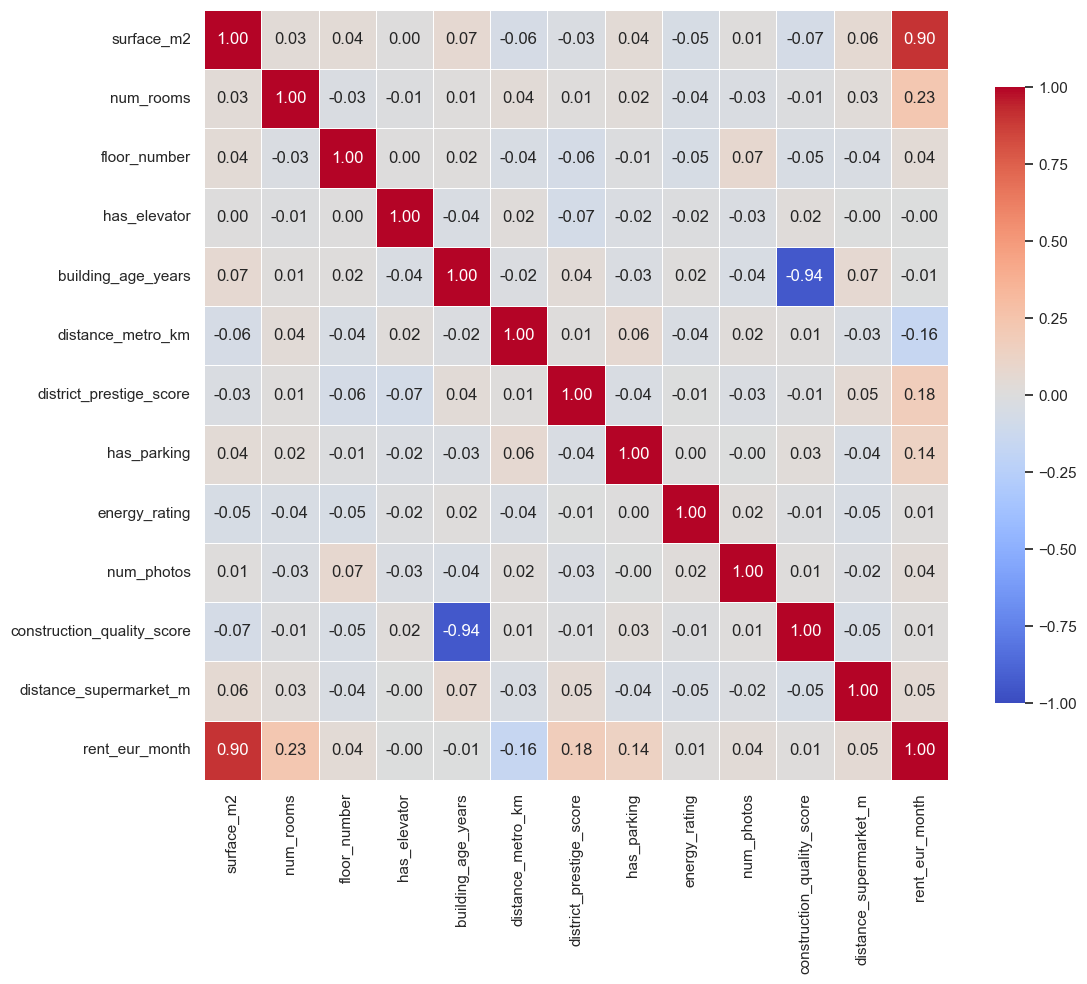

In [6]:
numeric_df = df_train.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr(method="spearman")

sns.set_theme(style="white", rc={"figure.figsize": (12, 10)})

sns.heatmap(
    corr_matrix,
    annot=True,  
    cmap="coolwarm",  
    fmt=".2f",  
    vmin=-1,
    vmax=1,  
    linewidths=0.5,  
    cbar_kws={"shrink": 0.8},  
)
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")

### 2.3 Deeper Inspection: Surface Area vs. Rent
**We observe** a massive positive correlation ($r = 0.93$) between `surface_m2` and `rent_eur_month` in our heatmaps. 

Because this looks like our most dominant predictor, **we want to visually inspect** this relationship using a scatter plot to check for distribution patterns and potential leverage points or outliers.

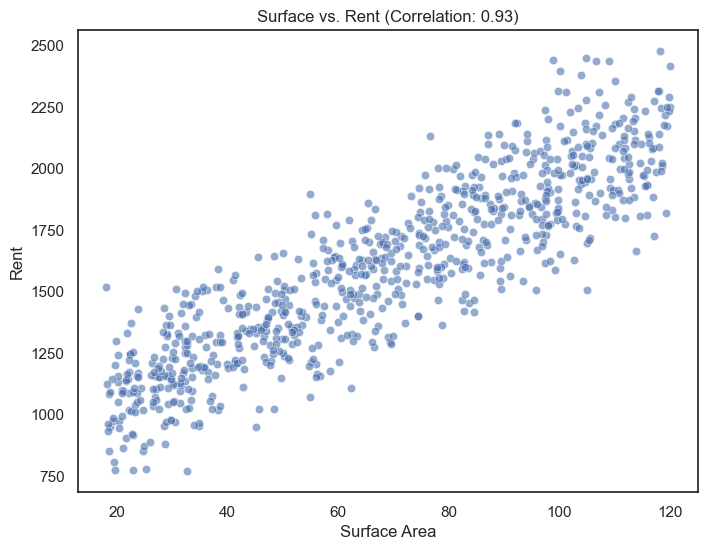

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_train, x="surface_m2", y="rent_eur_month", alpha=0.6)
plt.title("Surface vs. Rent (Correlation: 0.93)")
plt.xlabel("Surface Area")
plt.ylabel("Rent")
plt.show()

### 2.4 EDA Insights & Next Steps
* **Observation 1:** There is a nearly linear relationship between rent and surface area. When analyzing just the surface feature against the target, there are no obvious extreme outliers.
* **Observation 2:** We also notice a strong negative correlation between the property's quality score and its building age in years (older buildings tend to have lower quality scores).

**Thus, we want to try** establishing a simple Linear Regression model as our evaluation baseline to see how far these strong linear signals take us.

## 3. Baseline Model (Linear Regression)
We will fit a standard OLS Linear Regression on the training dataset and evaluate it using $R^2$, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) to bring our penalty metrics back into the original unit (Euros).

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

baseline_model = LinearRegression()
baseline_model.fit(X_train, Y_train)

Y_pred_train = baseline_model.predict(X_train)
Y_pred_test = baseline_model.predict(X_test)

mse_train = mean_squared_error(Y_train, Y_pred_train)
mse_test = mean_squared_error(Y_test, Y_pred_test)

print("--- Baseline Linear Regression Performance ---")
print(f"Training R-squared: {r2_score(Y_train, Y_pred_train):.4f}")
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test):.4f}")
print("-" * 40)
print(f"Training MSE:       {mse_train:.2f}")
print(f"Testing MSE:        {mse_test:.2f}")
print("-" * 40)
print(f"Training RMSE:      €{np.sqrt(mse_train):.2f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test):.2f}")

--- Baseline Linear Regression Performance ---
Training R-squared: 0.9262
Testing R-squared:  0.9389
----------------------------------------
Training MSE:       9707.05
Testing MSE:        8800.02
----------------------------------------
Training RMSE:      €98.52
Testing RMSE:       €93.81


## 4. Advanced Diagnostics: Outlier Detection via Cook's Distance
---
**We observe** that our linear model has a solid $R^2$, but **we want to inspect** if specific data points are exerting an undue influence on our regression coefficients. 

**Thus, we want to try** calculating **Cook's Distance**, which measures the effect of deleting any single observation on the model's predicted values. Points with a high Cook's distance indicate potential outliers or high-leverage points.

--- Cook's Distance Diagnostics ---
Number of influential points detected (Distance > 0.00500): 41


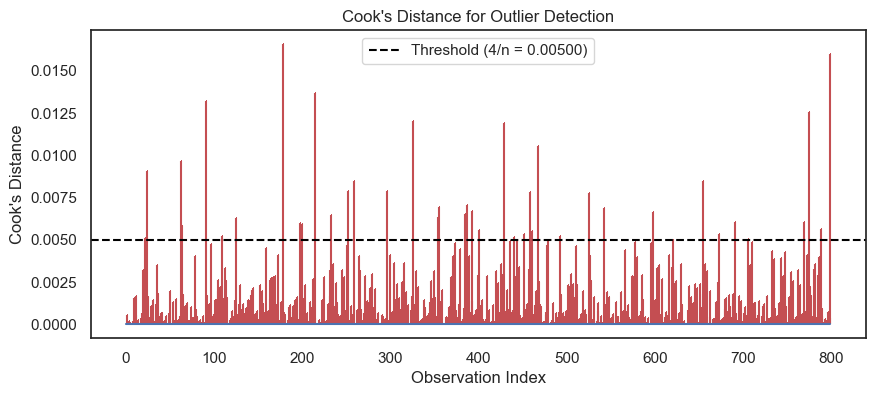

In [9]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

# Statsmodels requires an explicit intercept term
X_train_with_intercept = sm.add_constant(X_train)
stats_model = sm.OLS(Y_train, X_train_with_intercept).fit()

# Calculate leverage and Cook's distance
influence = OLSInfluence(stats_model)
cooks_dist, _ = influence.cooks_distance

# Define a standard threshold (4 / n)
threshold = 4 / len(X_train)
outliers_idx = np.where(cooks_dist > threshold)[0]

print(f"--- Cook's Distance Diagnostics ---")
print(f"Number of influential points detected (Distance > {threshold:.5f}): {len(outliers_idx)}")

# Plotting Cook's Distance
plt.figure(figsize=(10, 4))
plt.stem(np.arange(len(cooks_dist)), cooks_dist, markerfmt=",", linefmt="r-", basefmt="b-")
plt.axhline(y=threshold, color='black', linestyle='--', label=f'Threshold (4/n = {threshold:.5f})')
plt.title("Cook's Distance for Outlier Detection")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.show()

### 4.1 Data Cleaning based on Diagnostics
**We observe** that several points cross our threshold line. To ensure our models are robust and don't overfit to anomalies, **we want to try** dropping these high-leverage points from our training set before passing them to our non-linear models.

In [10]:
# Filter out the outliers found via Cook's Distance
X_train_clean = X_train.drop(X_train.index[outliers_idx])
Y_train_clean = Y_train.drop(Y_train.index[outliers_idx])

print(f"Original training shape: {X_train.shape}")
print(f"Cleaned training shape:  {X_train_clean.shape}")

Original training shape: (800, 12)
Cleaned training shape:  (759, 12)


## 5. Non-Linear Modeling: Ensemble Methods
---
Linear models assume a perfectly straight-line path, but features like building age, quality scores, and location often interact non-linearly. 

**Thus, we want to try** training powerful tree-based ensemble models: **Random Forest** (bagging) and **Gradient Boosting / LightGBM** (boosting) to capture these multi-variable relationships.

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb

# 1. Initialize models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)

# 2. Fit models on our cleaned training data
rf_model.fit(X_train_clean, Y_train_clean)
gb_model.fit(X_train_clean, Y_train_clean)
lgb_model.fit(X_train_clean, Y_train_clean)

print("Ensemble models successfully trained on clean data!")

Ensemble models successfully trained on clean data!


## 6. Final Evaluation & Model Comparison
---
**We want to inspect** how our new models compare against our initial baseline Linear Regression model using the raw test set ($X_{test}, Y_{test}$).

In [12]:
models = {
    "Linear Regression (Baseline)": baseline_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "LightGBM": lgb_model
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)
    mse = mean_squared_error(Y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_test, predictions)
    results.append({"Model": name, "R2 Score": r2, "MSE": mse, "RMSE (€)": rmse})

df_results = pd.DataFrame(results)
display(df_results.sort_values(by="RMSE (€)"))

,Model,R2 Score,MSE,RMSE (€)
0,Linear Regression (Baseline),0.938894,8800.021117,93.808428
2,Gradient Boosting,0.911650,12723.579872,112.798847
3,LightGBM,0.909579,13021.785781,114.113039
1,Random Forest,0.888688,16030.326889,126.610927


## 7. Feature Importance Verification
To close out our guided investigation, **we want to check** which features our best-performing model relies on most heavily. This confirms whether our numerical correlations align with the patterns the tree splits found.

C:\Users\kipra\AppData\Local\Temp\ipykernel_55808\2615565304.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x="Importance", y="Feature", palette="viridis")


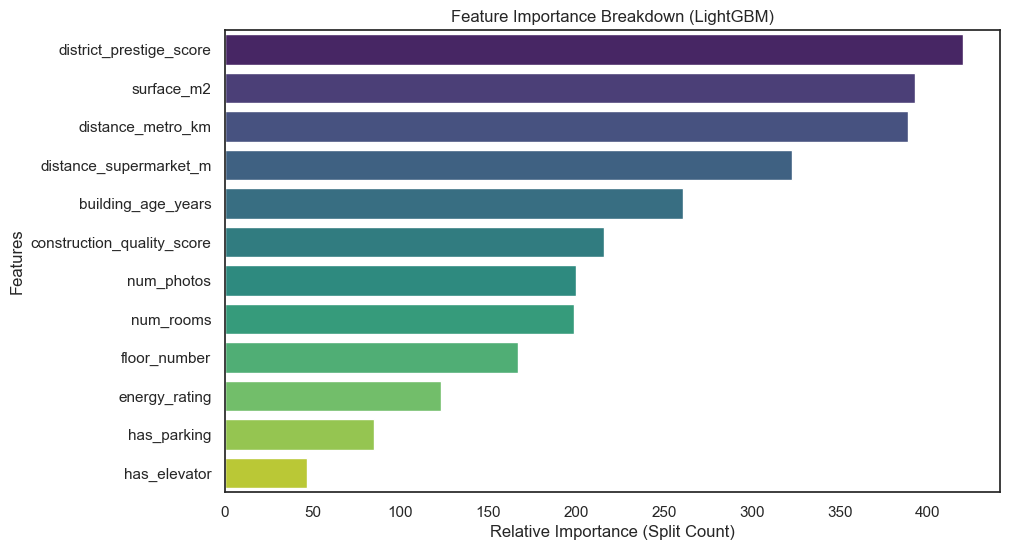

In [13]:
# Using LightGBM or Random Forest for Feature Importance
importances = lgb_model.feature_importances_
feature_names = X_train.columns

df_importance = pd.DataFrame({"Feature": feature_names, "Importance": importances})
df_importance = df_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance Breakdown (LightGBM)")
plt.xlabel("Relative Importance (Split Count)")
plt.ylabel("Features")
plt.show()